# Transfer Learning ile Hurma Çeşitlerinin Sınıflandırılması

Bu proje, "Date Fruit Image Dataset" veri setini kullanarak dokuz farklı hurma çeşidini (Ajwa, Medjool, Nabtat Ali..) sınıflandırmayı amaçlamaktadır. 

Transfer Öğrenimi (Transfer Learning): ResNet50 gibi önceden eğitilmiş (pre-trained) bir model kullanılarak yapılan sınıflandırma.

In [1]:
ls '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'

 Ajwa/     Medjool/  'Nabtat Ali'/   Shaishe/   Sugaey/
 Galaxy/   Meneifi/   Rutab/         Sokari/


In [2]:
# pip install -q protobuf==3.20.3

In [27]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import random
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import VGG16

import warnings
warnings.filterwarnings('ignore')
print("tf versiyon:", tf.__version__)

tf versiyon: 2.18.0


In [4]:
#Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu
def create_dataset(folders,path):
    data = {'imgpath': [], 'labels': []}
    for folder in folders:
        folderpath = os.path.join(path, folder)
        files = os.listdir(folderpath)
        
        for file in files:
            filepath = os.path.join(folderpath, file)
            data['imgpath'].append(filepath)
            data['labels'].append(folder)

    dataset = pd.DataFrame(data)
    return dataset

In [5]:
# Veri seti yollarını tanımlayalım
path = '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'
folders = ['Ajwa','Medjool', 'Nabtat Ali', 'Shaishe','Sugaey','Galaxy', 'Meneifi','Rutab','Sokari']

In [6]:
df=create_dataset(folders,path)

In [7]:
df.head()

,imgpath,labels
0,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
1,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
2,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
3,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
4,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa


In [8]:
df.shape

(1658, 2)

In [9]:
df

,imgpath,labels
0,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
1,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
2,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
3,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
4,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
...,...,...
1653,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1654,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1655,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1656,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari


In [10]:
len(df.labels.unique())

9

In [11]:
df.labels.unique()

array(['Ajwa', 'Medjool', 'Nabtat Ali', 'Shaishe', 'Sugaey', 'Galaxy',
       'Meneifi', 'Rutab', 'Sokari'], dtype=object)

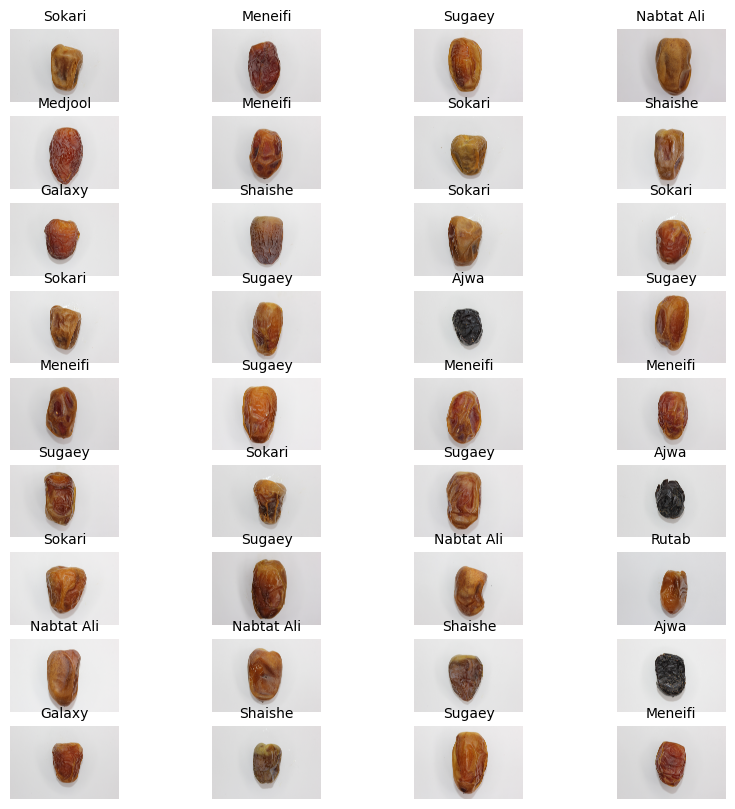

In [12]:
rows = 9
cols = 4
selected_indices = random.sample(range(len(df)), rows * cols)

fig, axes = plt.subplots(rows, cols, figsize = (10, 10))
gs = gridspec.GridSpec(rows, cols, wspace = 0.0, hspace = 0.0)

for i, idx in enumerate(selected_indices):
    row = i // cols
    col = i % cols
    img_path = df['imgpath'].iloc[idx]
    label = df['labels'].iloc[idx]
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(label, fontsize = 10)

plt.show()

In [13]:
# Veri setini etiketlere göre bölme
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['labels'])

In [14]:
# görsel ön işleme ve generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
seed = 42
batch_size = 64
img_size = (224, 224)

generator = ImageDataGenerator(rescale = 1./255)

train_data = generator.flow_from_dataframe(train_df, x_col = 'imgpath', y_col = 'labels', 
                                           color_mode = 'rgb', class_mode = 'categorical', 
                                           batch_size = batch_size, target_size = img_size, 
                                           shuffle = True, seed = seed)

val_data = generator.flow_from_dataframe(val_df, x_col = 'imgpath', y_col = 'labels', 
                                         color_mode = 'rgb', class_mode = 'categorical', 
                                         batch_size = batch_size, target_size = img_size, 
                                         shuffle = False)

test_data = generator.flow_from_dataframe(test_df, x_col = 'imgpath', y_col = 'labels', 
                                          color_mode = 'rgb', class_mode = 'categorical', 
                                          batch_size = batch_size, target_size = img_size, 
                                          shuffle = False)

Found 1326 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.


### Transfer Learning

In [15]:
# 1. VGG16 Modelini Yükleme (Transfer Learning)
# include_top=False: En sondaki 1000 sınıflı çıktı katmanını dahil etmez.
# weights='imagenet': ImageNet üzerinde eğitilmiş ağırlıkları kullanır.
# input_shape=(224, 224, 3)
base_model_vgg = VGG16(weights='imagenet', 
                       include_top=False, 
                       input_shape=(224, 224, 3))

I0000 00:00:1764883036.675706     127 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764883036.676315     127 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# 2. Mevcut Ağırlıkları Dondurma
# Base modelin ağırlıklarını eğitime kapatıyoruz ki ImageNet bilgilerini kaybetmesin.
for layer in base_model_vgg.layers:
    layer.trainable = False

In [17]:
# 3. Yeni Sınıflandırma Katmanlarını Ekleme
x = base_model_vgg.output
x = GlobalAveragePooling2D()(x) # VGG'nin çıktısı
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) 
predictions = Dense(9, activation='softmax')(x) # 9 Sınıf


In [18]:
# Modeli oluşturma
model_vgg_tl = Model(inputs=base_model_vgg.input, outputs=predictions)

In [19]:
# 4. Modeli Derleme (Compile)
# CategoricalCrossentropy kullanıyoruz çünkü veriler 'categorical' modda yüklendi.
model_vgg_tl.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [21]:
# Model Özetini Gösterme
model_vgg_tl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,249,225 (58.17 MB)

 Trainable params: 534,537 (2.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
# 5. Modeli Eğitme (Training)
# train_data ve val_data, önceki kodlarında tanımladığın generator'lardır.
# Callbacks olarak senin tanımladığın EarlyStopping ve ReduceLROnPlateau kullanılıyor.
history_transfer = model_vgg_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 2, restore_best_weights = True),
               ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 1, mode = 'min')]
)

Epoch 1/25


I0000 00:00:1764883246.813503     182 service.cc:148] XLA service 0x7e43c400e6c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764883246.814589     182 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764883246.814616     182 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764883247.248497     182 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-12-04 21:20:52.676771: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng36{k2=3,k3=0} for conv (f32[64,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_

21/21 ━━━━━━━━━━━━━━━━━━━━ 192s 8s/step - accuracy: 0.1485 - auc: 0.5515 - loss: 2.2655 - val_accuracy: 0.2590 - val_auc: 0.7827 - val_loss: 1.9146 - learning_rate: 0.0010
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.2864 - auc: 0.7564 - loss: 1.9078 - val_accuracy: 0.3313 - val_auc: 0.8933 - val_loss: 1.6456 - learning_rate: 0.0010
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.5134 - auc: 0.8768 - loss: 1.6170 - val_accuracy: 0.7349 - val_auc: 0.9552 - val_loss: 1.3723 - learning_rate: 0.0010
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.6440 - auc: 0.9295 - loss: 1.3896 - val_accuracy: 0.7952 - val_auc: 0.9693 - val_loss: 1.1666 - learning_rate: 0.0010
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.6740 - auc: 0.9457 - loss: 1.2074 - val_accuracy: 0.7711 - val_auc: 0.9651 - val_loss: 0.9969 - learning_rate: 0.0010
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 98s 5s/step - accuracy: 0.6927 - auc: 0.9490 - loss: 1.0668

In [24]:
# 6. Modeli Kaydetme
model_vgg_tl.save('date_fruit_vgg_tl.keras')
model_vgg_tl.save('date_fruit_vgg_tl.h5')

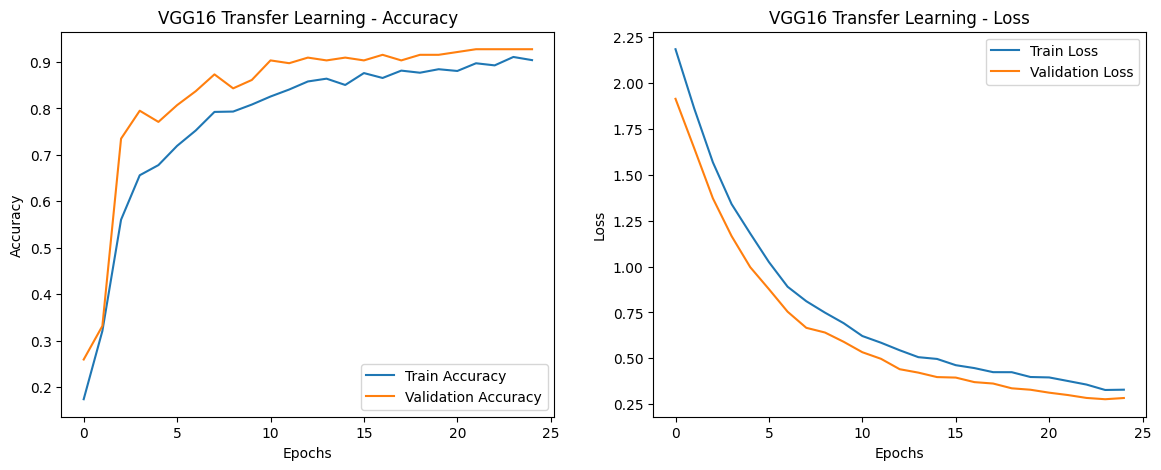

In [26]:
# Eğitim grafigi
plt.figure(figsize=(14, 5))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Transfer Learning - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Transfer Learning - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step


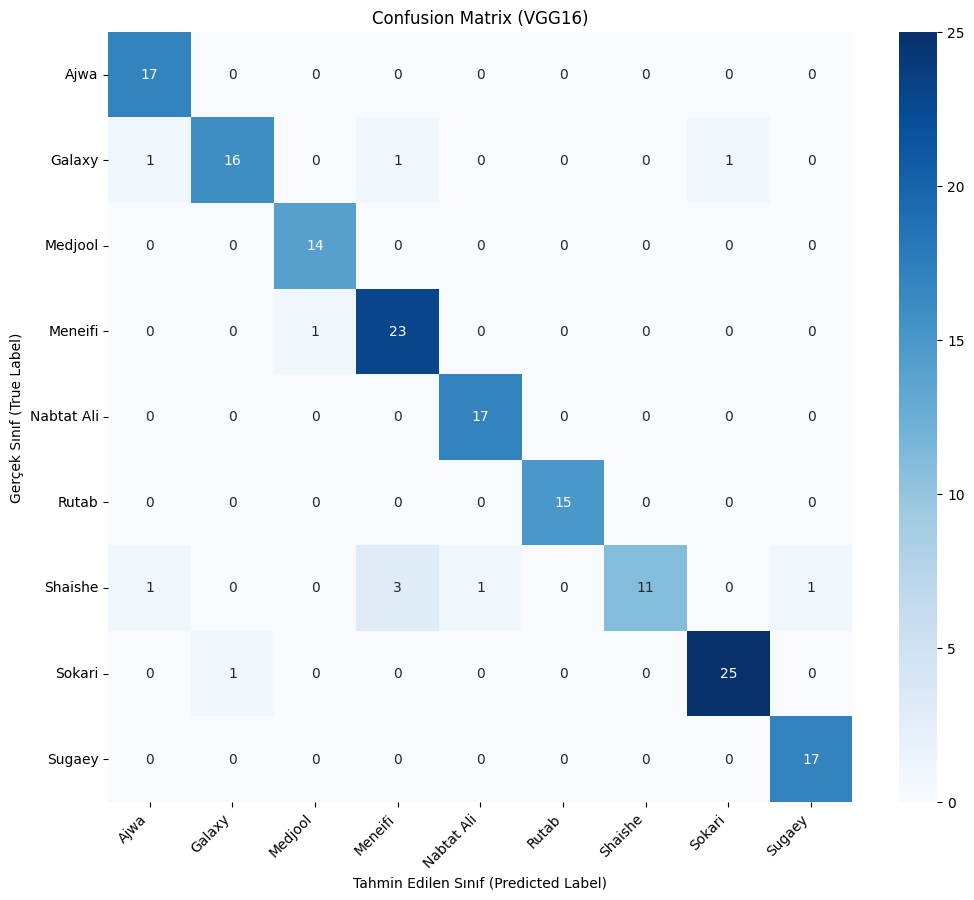


--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

        Ajwa       0.89      1.00      0.94        17
      Galaxy       0.94      0.84      0.89        19
     Medjool       0.93      1.00      0.97        14
     Meneifi       0.85      0.96      0.90        24
  Nabtat Ali       0.94      1.00      0.97        17
       Rutab       1.00      1.00      1.00        15
     Shaishe       1.00      0.65      0.79        17
      Sokari       0.96      0.96      0.96        26
      Sugaey       0.94      1.00      0.97        17

    accuracy                           0.93       166
   macro avg       0.94      0.93      0.93       166
weighted avg       0.94      0.93      0.93       166



In [28]:
# Tahminleri (Predictions) al
# Modeliniz (model_vgg_tl) ile test_data üzerinde tahmin yapın
y_pred_probs = model_vgg_tl.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1) # En yüksek olasılığa sahip sınıf indeksini alın

# Gerçek Etiketleri (True Labels) Alın
y_true = test_data.classes # Test verisindeki gerçek indeksler
class_labels = list(test_data.class_indices.keys()) # Sınıf isimleri

# Confusion Matrix'i hesaplayın
cm = confusion_matrix(y_true, y_pred)

# Matrisi görselleştirin
plt.figure(figsize=(12, 10)) # Boyutu artırıldı
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix (VGG16)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.xticks(rotation=45, ha='right') # Etiketleri döndürme
plt.yticks(rotation=0)
plt.show()

# --- Sınıflandırma Raporu (Classification Report) ---
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

Sonuclara bbaktigimizda gayet basarili. Hurma modelini istenilen kisimlarda kullanilabilir.